In [19]:
import os
import numpy as np
import glob
import PIL.Image as Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
import torch.optim as optim
from time import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
import sys
import os
sys.path.append('/zhome/45/0/155089/Deeplear/ning_in_computer_vision/Segmentation_project/Asignments_DeepLearningForCV/')  
sys.path.append("/zhome/b6/d/154958/IDLICV/Segmentation_project/Asignments_DeepLearningForCV/")
from Performance_Metrics import dice_coefficient, intersection_over_union, accuracy, sensitivity, specificity
#import dataset DRIVE 
from DRIVE_dataloader import train_patch_loader , val_patch_loader, test_patch_loader,  train_loader, val_loader, test_loader
import time 
from time import time  # Correct import
class EncDec(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc_conv0 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn_enc0 = nn.BatchNorm2d(64)
        self.pool0 = nn.MaxPool2d(2, 2)
        
        self.enc_conv1 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn_enc1 = nn.BatchNorm2d(128)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.enc_conv2 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn_enc2 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.enc_conv3 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn_enc3 = nn.BatchNorm2d(512)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck_conv = nn.Conv2d(512, 1024, 3, padding=1)
        self.bn_bottleneck = nn.BatchNorm2d(1024)

        # Decoder
        self.upsample0 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec_conv0 = nn.Conv2d(1024, 512, 3, padding=1)
        self.bn_dec0 = nn.BatchNorm2d(512)
        
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec_conv1 = nn.Conv2d(512, 256, 3, padding=1)
        self.bn_dec1 = nn.BatchNorm2d(256)
        
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec_conv2 = nn.Conv2d(256, 128, 3, padding=1)
        self.bn_dec2 = nn.BatchNorm2d(128)
        
        self.upsample3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec_conv3 = nn.Conv2d(128, 64, 3, padding=1)
        self.bn_dec3 = nn.BatchNorm2d(64)
        self.upsample_final = nn.Upsample(110, mode = "bilinear", align_corners=True)

        # Final Layer
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        
    def forward(self, x):
        # Encoder
        e0 = self.pool0(F.relu(self.bn_enc0(self.enc_conv0(x))))
        e1 = self.pool1(F.relu(self.bn_enc1(self.enc_conv1(e0))))
        e2 = self.pool2(F.relu(self.bn_enc2(self.enc_conv2(e1))))
        e3 = self.pool3(F.relu(self.bn_enc3(self.enc_conv3(e2))))

        # Bottleneck
        b = F.relu(self.bn_bottleneck(self.bottleneck_conv(e3)))

        # Decoder
        d0 = F.relu(self.bn_dec0(self.dec_conv0(self.upsample0(b))))
        d1 = F.relu(self.bn_dec1(self.dec_conv1(self.upsample1(d0))))
        d2 = F.relu(self.bn_dec2(self.dec_conv2(self.upsample2(d1))))
        d3 = F.relu(self.bn_dec3(self.dec_conv3(self.upsample3(d2))))

        # Final Output with Sigmoid activation
        out = torch.sigmoid(self.final_conv( self.upsample_final(d3)))
        return out


from Unet_DRIVE import train
from UNet2 import focal_loss_chatten, stable_bce_loss
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Thresholding for binary masks
    y_pred = (y_pred > 0.5).float()
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
   
    intersection = (y_true_f * y_pred_f).sum()
    return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

def intersection_over_union(y_true, y_pred, smooth=1e-6):
    # Thresholding for binary masks
    y_pred = (y_pred > 0.5).float()
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def accuracy(y_true, y_pred):
    y_pred = (y_pred > 0.5).float()  # Thresholding
    correct = (y_true == y_pred).float().sum()  # Count of correct predictions
    return correct / y_true.numel()  # Total number of pixels

def sensitivity(y_true, y_pred):
    y_pred = (y_pred > 0.5).float()  # Thresholding
    true_positives = (y_true * y_pred).sum()
    possible_positives = y_true.sum()
    return true_positives / (possible_positives + 1e-6)  # Avoid division by zero

def specificity(y_true, y_pred):
    y_pred = (y_pred > 0.5).float()  # Thresholding
    true_negatives = ((1 - y_true) * (1 - y_pred)).sum()
    possible_negatives = (1 - y_true).sum()
    return true_negatives / (possible_negatives + 1e-6)  # Avoid division by zero

def test_a(model, test_loader, loss_fn):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    all_y_true = []
    all_y_pred = []

    with torch.no_grad():  # Disable gradient calculation
        for X_test_batch, Y_test_batch in test_loader:
            X_test_batch = X_test_batch.to(device)
            Y_test_batch = Y_test_batch.to(device)

            Y_test_pred = model(X_test_batch)
            Y_test_pred = torch.sigmoid(Y_test_pred)
            
            loss = loss_fn(Y_test_batch,Y_test_pred )  # Compute test loss
            test_loss += loss.item()  # Accumulate test loss

            all_y_true.append(Y_test_batch.cpu())
            all_y_pred.append(Y_test_pred.cpu())

    avg_test_loss = test_loss / len(test_loader)
    print('Test Loss: %f' % avg_test_loss)

    # Concatenate all predictions and ground truths
    all_y_true = torch.cat(all_y_true)
    all_y_pred = torch.cat(all_y_pred)

    # Calculate metrics
    dice = dice_coefficient(all_y_true, all_y_pred)
    iou = intersection_over_union(all_y_true, all_y_pred)
    acc = accuracy(all_y_true, all_y_pred)
    sens = sensitivity(all_y_true, all_y_pred)
    spec = specificity(all_y_true, all_y_pred)

    # Print metrics
    print(f'Dice: {dice:.4f}, IoU: {iou:.4f}, Accuracy: {acc:.4f}, Sensitivity: {sens:.4f}, Specificity: {spec:.4f}')

    return loss_fn,[dice,iou,acc,sens,spec]
def bce_total_variation_(y_real, y_pred, tv_weight=0.01):
    # Compute sigmoid activation for y_pred
    sigmoid_pred = torch.sigmoid(y_pred)
    
    # Calculate binary cross-entropy loss
    bce_loss = stable_bce_loss(y_real, y_pred)
    
    # Calculate total variation loss
    # Assume y_pred is in shape [batch, channels, height, width]
    # diff_i = torch.abs(sigmoid_pred[:, :, 1:, :] - sigmoid_pred[:, :, :-1, :]).sum()
    # diff_j = torch.abs(sigmoid_pred[:, :, :, 1:] - sigmoid_pred[:, :, :, :-1]).sum()
    # tv_loss = tv_weight * (diff_i + diff_j)
    
    # Combine BCE and total variation losses
    return bce_loss + (sigmoid_pred*tv_weight)
def bce_sparsity_loss(y_real, y_pred, sparsity_weight=0.000001):
    # Compute sigmoid activation for y_pred
    sigmoid_pred = torch.sigmoid(y_pred)
    
    # Calculate binary cross-entropy loss
    bce_loss = stable_bce_loss(y_real, y_pred)
    
    # Calculate sparsity loss (L1 norm on the predictions)
    sparsity_loss = sparsity_weight * torch.sum(sigmoid_pred)
    
    # Combine BCE and sparsity losses
    return bce_loss + sparsity_loss

def stable_bce_loss(y_real, y_pred):
    # Preventing overflow by using max(y_pred, 0)
    max_val = torch.clamp(y_pred, min=0)  # clamp to ensure y_pred is at least 0
    loss = max_val - y_real * y_pred + torch.log1p(torch.exp(-torch.abs(y_pred)))
    return torch.mean(loss)

def combined_loss(y_true, y_pred):
    bce = stable_bce_loss(y_pred, y_true)
    dice = dice_loss(y_true, y_pred)
    return bce + dice
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
def dice_loss(y_real, y_pred, epsilon=1e-6):
    y_pred = torch.sigmoid(y_pred)  # Apply sigmoid for binary segmentation
    intersection = (y_pred * y_real).sum()  # Sum over the batch and spatial dimensions
    numerator = 2 * intersection + epsilon
    denominator = y_pred.sum() + y_real.sum() + epsilon
    loss = 1 - numerator / denominator
    return loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EncDec().to(device)   

summary(model, input_size=(3,110,110))


test_dict = {}
for loss_fn in [stable_bce_loss,bce_sparsity_loss]: 
    model.apply(init_weights)
    train(model, optim.Adam(model.parameters(), 0.001), loss_fn, 100, train_patch_loader, val_patch_loader)
    key, performance = test_a(model, train_patch_loader, loss_fn) 
    test_dict[loss_fn.__name__] = performance
    torch.save(model, f"Enc_dec_drive_models/{loss_fn.__name__}_model.pkl")



Testing model nr 1, focal_loss_chatten
Test Loss: 0.776835
Dice: 0.0012, IoU: 0.0006, Accuracy: 0.9075, Sensitivity: 0.0006, Specificity: 1.0000


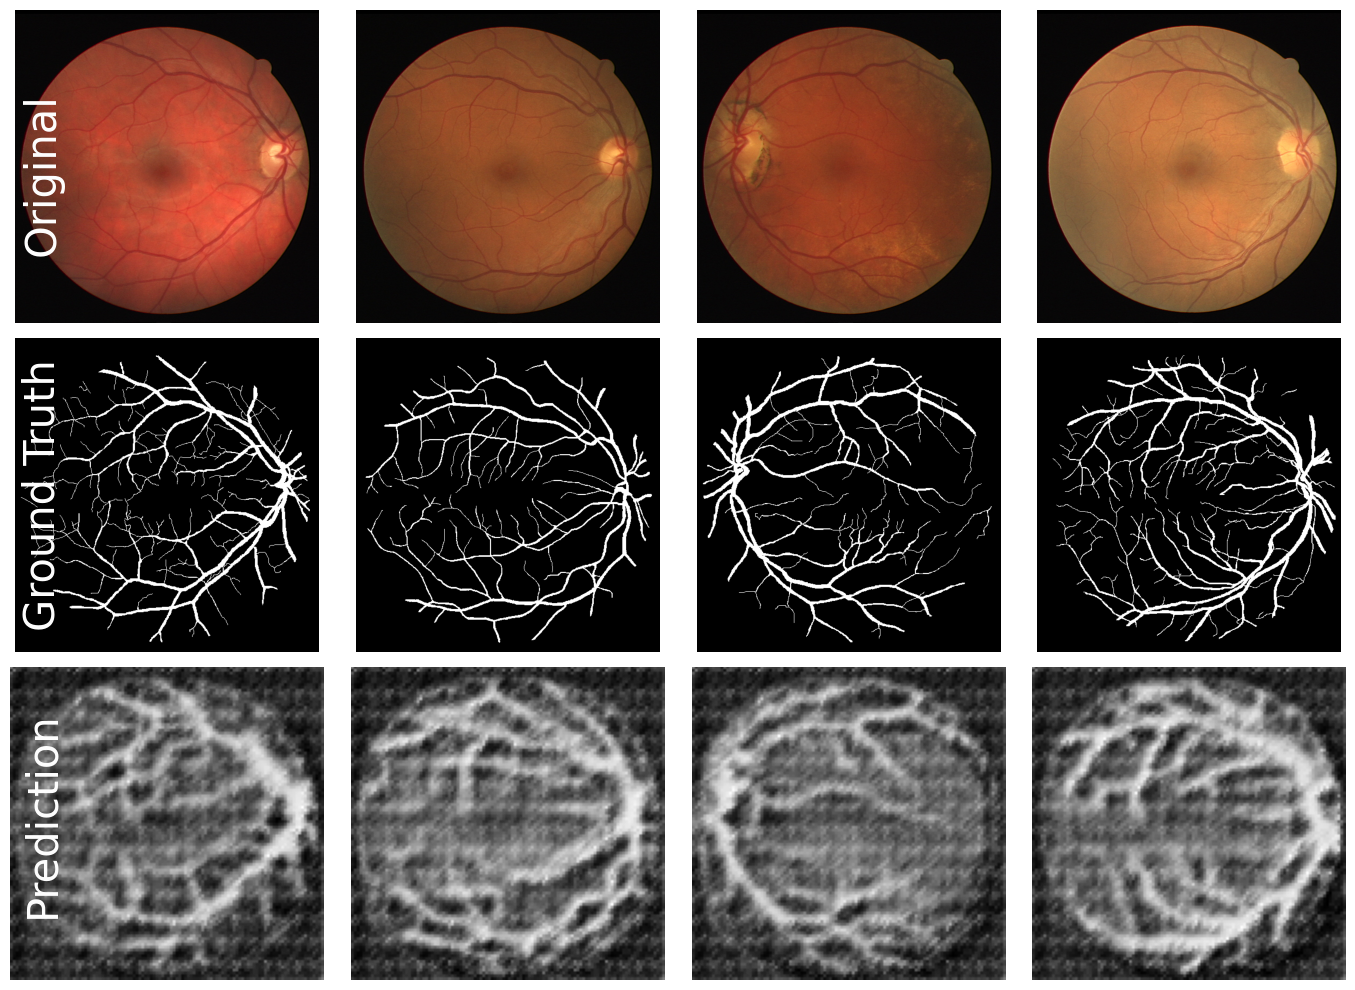

{}


In [13]:
from EncDecDRIVE_TRAINING_TESTING import visualize_test_predictions
from Encoder_Decoder_DRIVE import device

test_dict = {}
counter = 0
for file in os.listdir("Enc_dec_drive_models/"):
    if file.endswith("chatten_model.pkl"):
        counter += 1 
        model_name = "_".join(file.split("_")[0:-1])
        print(f"Testing model nr {counter}, {model_name}")
        model = torch.load("Enc_dec_drive_models/"+file, weights_only=False)
        key, performance = test_a(model, test_patch_loader, stable_bce_loss) 
        # test_dict[model_name] = performance
        visualize_test_predictions(model, test_loader, device)
print(test_dict)

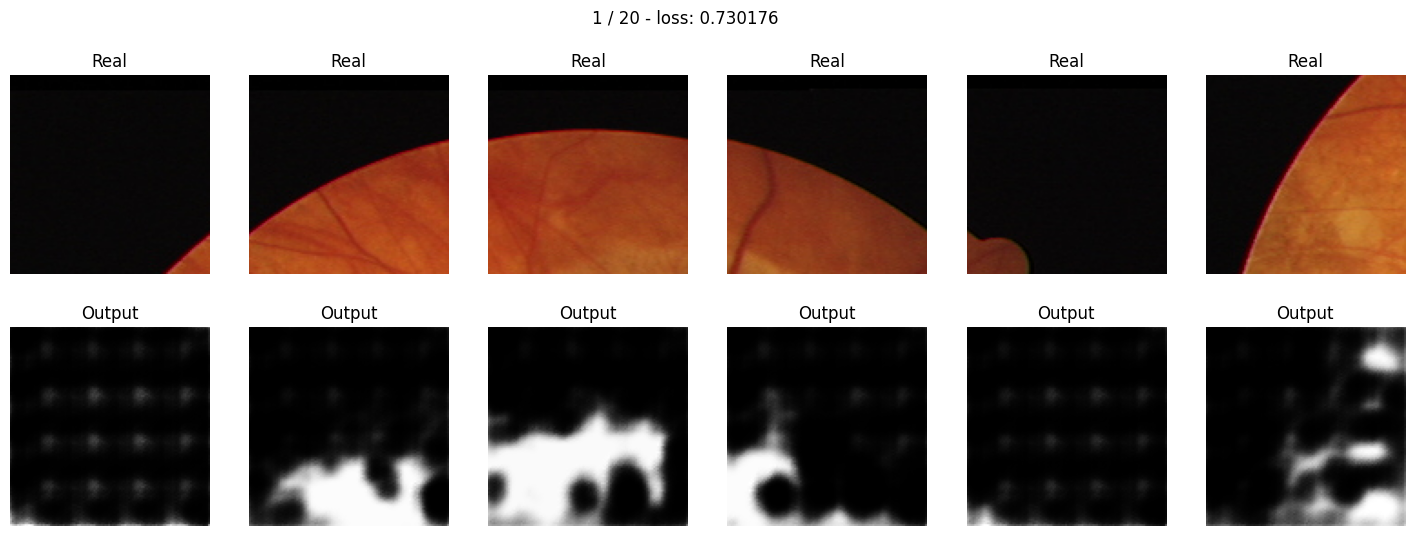

* Epoch 2/20
 - loss: 0.681298
* Epoch 3/20
 - loss: 0.673351
* Epoch 4/20
 - loss: 0.669497
* Epoch 5/20
 - loss: 0.664421
* Epoch 6/20
 - loss: 0.651943
* Epoch 7/20
 - loss: 0.645268
* Epoch 8/20


Exception ignored in: <function _releaseLock at 0x7f1fce5e3600>
Traceback (most recent call last):
  File "/appl9/python/3.11.4/lib/python3.11/logging/__init__.py", line 237, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


RuntimeError: DataLoader worker (pid(s) 1694905) exited unexpectedly

In [14]:
train(model, optim.Adam(model.parameters(),0.001), dice_loss,20,train_patch_loader,val_patch_loader)